Rozkład normalny
https://www.youtube.com/watch?v=XAnPvoPzoxQ

mi - u  = średnia
sigma - odchylenie standardowe - std



Empirical mean: 9.9290, Empirical std: 2.2436
Theoretical mean: 10.0, Theoretical variance: 5.0000


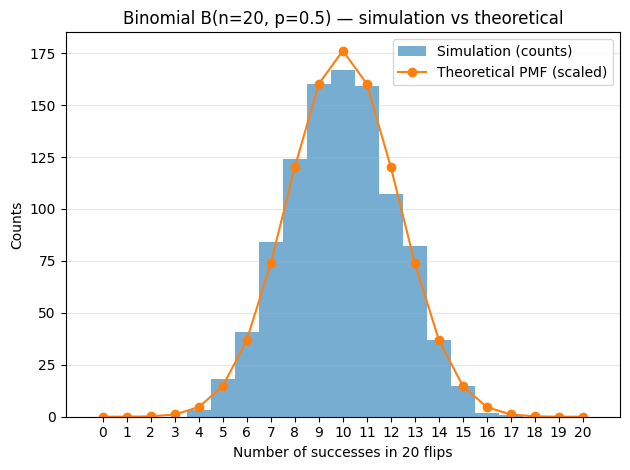

In [ ]:
# Zadanie 9 – Rozkład dwumianowy - symulacja
# Symuluj 1000 eksperymentów rzutu 20 monetami (p=0.5). 
# Porównaj histogram wyników z teoretycznym rozkładem dwumianowym B(20, 0.5).
# 
# Dataset:
#     Wygeneruj używając np.random.binomial()

# Wymagania:
#     Symulacja 1000 eksperymentów
#     Histogram wyników symulacji
#     Teoretyczny PMF rozkładu B(20, 0.5) nałożony na histogram
#     Porównanie średniej empirycznej z teoretyczną


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
from math import comb

n_prob = 1000
n_flips = 20
p = 0.5

# Symulacja: 1000 eksperymentów, każdy to liczba sukcesów w 20 rzutach
np.random.seed(42)
sim = np.random.binomial(n_flips, p, size=n_prob)  # shape (1000,)
#print(sim)

# Empiryczne statystyki
emp_mean = sim.mean()
emp_std = sim.std()
theo_mean = n_flips * p
theo_var = n_flips * p * (1 - p)

print(f"Empirical mean: {emp_mean:.4f}, Empirical std: {emp_std:.4f}")
print(f"Theoretical mean: {theo_mean}, Theoretical variance: {theo_var:.4f}")

# Histogram symulacji
counts, bins, patches = plt.hist(sim, bins=np.arange(-0.5, n_flips+1.5, 1), density=False, alpha=0.6, color='C0', label='Simulation (counts)')

# Teoretyczny PMF (skala liczebności: pmf * n_prób)
k = np.arange(0, n_flips+1)
pmf = binom.pmf(k, n_flips, p)           # scipy.stats binomial PMF
plt.plot(k, pmf * n_prob, 'o-', color='C1', label='Theoretical PMF (scaled)')

# Opcje wykresu
plt.xlabel('Number of successes in 20 flips')
plt.ylabel('Counts')
plt.title(f'Binomial B(n={n_flips}, p={p}) — simulation vs theoretical')
plt.xticks(k)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



Statystyki przed:
 count     1599.000000
mean        10.422983
median      10.200000
std          1.065668
min          8.400000
max         14.900000
Name: before, dtype: float64 

Liczba wykrytych outlierów w 'alcohol': 8

Statystyki po:
 count     1591.000000
mean        10.404431
median      10.100000
std          1.035413
min          8.400000
max         13.600000
Name: after, dtype: float64 

Porównanie before vs after:
              before        after
count   1599.000000  1591.000000
mean      10.422983    10.404431
median    10.200000    10.100000
std        1.065668     1.035413
min        8.400000     8.400000
max       14.900000    13.600000 



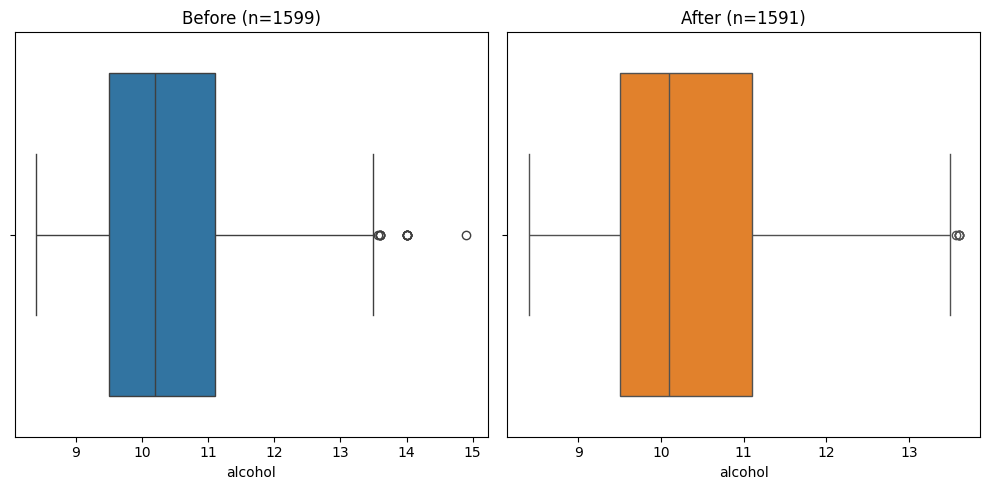

Przykładowe outliery:
      alcohol  z_alcohol
142     14.0   3.356597
144     14.0   3.356597
467     14.0   3.356597
588     14.0   3.356597
652     14.9   4.201138


In [ ]:
# 10. ✏️ Zadanie 10 – Wykrywanie outliers metodą z-score
# Dla datasetu Wine Quality zidentyfikuj outliery w kolumnie alcohol metodą z-score (wartości > mean ± 3*std). 
# Usuń outliery i porównaj statystyki przed/po.
# Dataset:
#     Wine Quality

# Wymagania:
#     Oblicz z-scores
#     Zidentyfikuj outliery (|z| > 3)
#     Boxplot przed i po usunięciu
#     Porównanie statystyk (mean, median, std)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie datasetu (przykład: winequality-red)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# Kolumna do analizy
col = 'alcohol'

# Statystyki przed
stats_before = df[col].agg(['count', 'mean', 'median', 'std', 'min', 'max']).rename('before')
print("Statystyki przed:\n", stats_before, "\n")

# Oblicz z-score 
mean = df[col].mean()
std = df[col].std()
z_scores = (df[col] - mean) / std
df['z_alcohol'] = z_scores

# outliery |z| > 3
outliers_mask = z_scores.abs() > 3
n_outliers = outliers_mask.sum()
print(f"Liczba wykrytych outlierów w '{col}': {n_outliers}\n")

# DF bez outlierów
df_no_out = df[~outliers_mask].copy()

# Statystyki po usunięciu
stats_after = df_no_out[col].agg(['count', 'mean', 'median', 'std', 'min', 'max']).rename('after')
print("Statystyki po:\n", stats_after, "\n")

# Porównanie statystyk (pojedyncza tabela)
comparison = pd.concat([stats_before, stats_after], axis=1)
print("Porównanie before vs after:\n", comparison, "\n")

# Boxplot przed i po
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(x=df[col], color='C0')
plt.title(f"Before (n={int(stats_before['count'])})")
plt.xlabel(col)

plt.subplot(1,2,2)
sns.boxplot(x=df_no_out[col], color='C1')
plt.title(f"After (n={int(stats_after['count'])})")
plt.xlabel(col)

plt.tight_layout()
plt.show()


# Opcjonalnie: wypisz wiersze wykrytych outlierów
if n_outliers > 0:
    print("Przykładowe outliery:\n", df.loc[outliers_mask, [col, 'z_alcohol']].head())
